Utilizzando il dataset Diabetes, replica l'esercitazione pratica di Python:
- Effettuare la standarizzazione dei dati
- Addestrare una regressione lineare, e calcolare MSE e R2
- Addestrare una regressione Lasso con 100 valori di alpha e per ognuno calcolare MSE e R2, determinando il miglior alpha
- Addestrare una regressione LassoCV con stessi valori di alpha e per ognuno calcolare MSE e R2, determinando il miglior alpha
- Plottare i valori di MSE e R2, in funzione dei valori di alpha su uno stesso grafico (twinx)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso, LassoCV, LinearRegression

Utilizza dataset load_diabetes

In [2]:
data=load_diabetes(as_frame=True)
X=data.data
y=data.target
display(X)
display(y)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

- Effettuare la standarizzazione dei dati

In [3]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
display(X_scaled)

array([[ 0.80050009,  1.06548848,  1.29708846, ..., -0.05449919,
         0.41853093, -0.37098854],
       [-0.03956713, -0.93853666, -1.08218016, ..., -0.83030083,
        -1.43658851, -1.93847913],
       [ 1.79330681,  1.06548848,  0.93453324, ..., -0.05449919,
         0.06015558, -0.54515416],
       ...,
       [ 0.87686984,  1.06548848, -0.33441002, ..., -0.23293356,
        -0.98564884,  0.32567395],
       [-0.9560041 , -0.93853666,  0.82123474, ...,  0.55838411,
         0.93616291, -0.54515416],
       [-0.9560041 , -0.93853666, -1.53537419, ..., -0.83030083,
        -0.08875225,  0.06442552]])

- Addestrare una regressione lineare, e calcolare MSE e R2

In [4]:
lin_reg=LinearRegression()
lin_reg.fit(X_scaled,y)
y_pred_lin=lin_reg.predict(X_scaled)

mse_lin=mean_squared_error(y,y_pred_lin)
r2_lin=r2_score(y,y_pred_lin)

print(f"MSE:\t{mse_lin}, R2:\t{r2_lin}")

MSE:	2859.6963475867506, R2:	0.5177484222203498


- Addestrare una regressione Lasso con 100 valori di alpha e per ognuno calcolare MSE e R2, determinando il miglior alpha

In [5]:
r2_lasso=[]
mse_lasso=[]
alpha=np.logspace(-4,1,100)

for a in alpha:
    lasso=Lasso(alpha=a)
    lasso.fit(X_scaled,y)
    y_pred=lasso.predict(X_scaled)
    mse_lasso.append(mean_squared_error(y,y_pred))
    r2_lasso.append(r2_score(y,y_pred))
risultati=pd.DataFrame({"alpha": alpha,"MSE":mse_lasso, "R2":r2_lasso})
display(risultati)

,alpha,MSE,R2
0,0.000100,2859.696352,0.517748
1,0.000112,2859.696353,0.517748
2,0.000126,2859.696355,0.517748
3,0.000142,2859.696357,0.517748
4,0.000159,2859.696359,0.517748
...,...,...,...
95,6.280291,3092.095569,0.478557
96,7.054802,3112.199202,0.475167
97,7.924829,3137.556595,0.470891
98,8.902151,3169.553655,0.465495


trovo indice che minimizza mse

In [12]:
best_index_man=np.argmin(mse_lasso)
best_alpha_man=alpha[best_index_man]
best_mse_man=mse_lasso[best_index_man]
best_r2_man=r2_lasso[best_index_man]
zero_lasso = sum(coef == 0 for coef in lasso.coef_)

print(f"Alpha LASSO: {best_alpha_man}\nMSE:\t{best_mse_man}\nR2:\t {best_r2_man}")
print (f"Con lasso  {zero_lasso}/{len(lasso.coef_)} variabili sono diventate zero")

Alpha LASSO: 0.0001
MSE:	2859.696352208495
R2:	 0.5177484214409511
Con lasso  6/10 variabili sono diventate zero


- Addestrare una regressione LassoCV con stessi valori di alpha e per ognuno calcolare MSE e R2, determinando il miglior alpha

In [11]:
alphas_cv = alpha
lasso_cv = LassoCV(alphas=alphas_cv, cv=5, random_state=42, max_iter=1000)
lasso_cv.fit(X_scaled, y)

print(F"Alpha LassoCV:\t{lasso_cv.alpha_}")

y_pred_cv = lasso_cv.predict(X_scaled)
mse_cv = mean_squared_error(y, y_pred_cv)
r2_cv = r2_score(y, y_pred_cv)
zero_lasso_cv = sum(coef == 0 for coef in lasso_cv.coef_)

print(f"MES:\t{mse_cv}\nR2:\t{r2_cv}")
print (f"Con lasso CV  {zero_lasso_cv}/{len(lasso_cv.coef_)} variabili sono diventate zero")

Alpha LassoCV:	0.07564633275546291
MES:	2861.6015825329255
R2:	0.5174271284719386
Con lasso CV  1/10 variabili sono diventate zero


- Plottare i valori di MSE e R2, in funzione dei valori di alpha su uno stesso grafico (twinx)

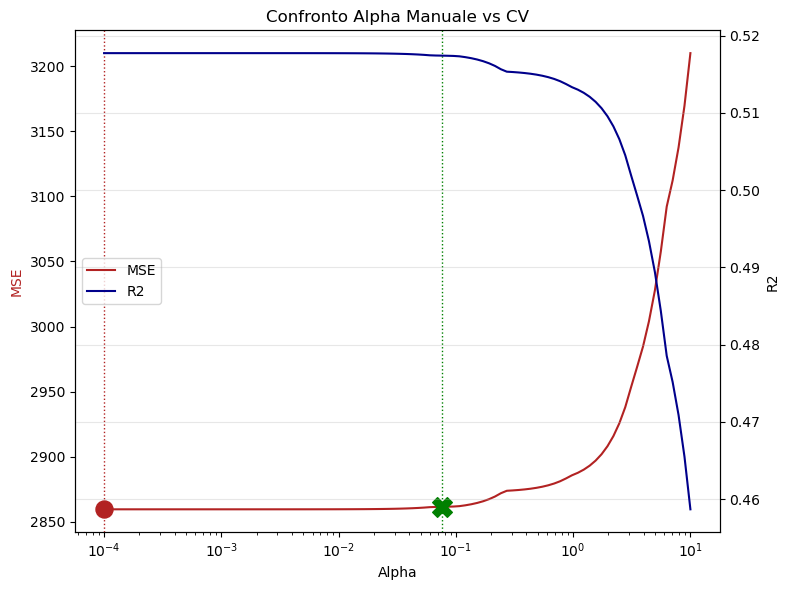

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 6))

l1 = ax1.plot(alpha, mse_lasso, '-', color='firebrick', label='MSE')
ax1.set_xscale('log')
ax1.set_xlabel('Alpha')
ax1.set_ylabel('MSE', color='firebrick')

ax1.scatter(best_alpha_man, best_mse_man, color='firebrick', s=150, zorder=5, label='Alpha Ottimale Manuale')
ax1.axvline(best_alpha_man, color='firebrick', linestyle=':', linewidth=1)

ax1.scatter(lasso_cv.alpha_, mse_cv, color='green', marker='X', s=200, zorder=5, label='Alpha Ottmale CV')
ax1.axvline(lasso_cv.alpha_, color='green', linestyle=':', linewidth=1)

ax2 = ax1.twinx()
l2 = ax2.plot(alpha, r2_lasso, '-', color='darkblue', label='R2')
ax2.set_ylabel('R2')

plt.title('Confronto Alpha Manuale vs CV')
plt.grid(alpha=0.3)

lines = l1 + l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='center left')

plt.tight_layout()
plt.show()



L'MAE misura l'errore medio in valore assoluto (esempio reale=100 pred=90 errore=10)
R2 (coefficiente di determinazione) quando il medello spiega i dati 1=perfetto 0=inutile <0peggio della media
Con Lasso ho anche alpha_ come parametro valori alti=modello semplice (meno variabili) basso=modello complesso
Inoltre il semplice Lasso azzera ben 6 variabili mentre Lasso CV solo 1, questo vuol dire che Lasso sta forzando troppo la semplificazione, mentre Lasso CV sta ascoltando i dati -> Lasso CV è più affidabile
Quindi Lasso CV solo 1 variabile eliminata  però con performance simili a Lasso base. Lasso base è più semplice ma meno realistico

In [13]:
print("LassoCV alpha:", lasso_cv.alpha_)
print("Coefficienti:", lasso_cv.coef_)

LassoCV alpha: 0.07564633275546291
Coefficienti: [ -0.31376479 -11.23525041  24.81085641  15.27583092 -27.18498065
  14.48945371   0.           6.80053107  31.91028091   3.18224005]


Su questo dataset quindi LassoCV meglio di Lasso

Ora confrontiamo con Ridge

In [14]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-4,1,100), cv=5)
ridge.fit(X_scaled, y)

print("Ridge R2:", ridge.score(X_scaled, y))

Ridge R2: 0.5177413473553172


Ridge R² ≈ 0.5177
LassoCV R² ≈ 0.5174
Lasso manuale ≈ 0.5177

sono uguali

Il modello non cambia il risultato, non è Ridge migliore o Lasso migliore, i dati limitano il modello.
Questo significa:
- relazione quasi lineare
- poche interazioni non lineari
- regularization inutile
In questo caso è possibile usare anche una semplice regressione Lineare, non serve Ridge e non serve Lasso

Per la variabili (feature):
Lasso ne elimina 6 mentre Lasso CV solo 1, ma le performance tra i due modelli sono simili, pertanto le varibili NON stanno migliorando il modello. E' possibile tenere poche variabili, perchè si perde poca precesione.